# Feature Selection — Data-Driven (No Prior Exclusion)

**Research context:** Binary classification of NFL play-calls (pass vs. run).

Unlike feature_selection_mini, this notebook applies **no structural pre-exclusion**. All columns survive stage 1 and are evaluated empirically. The goal is to let the data show which features associate with the target — the decision about what is truly pre-snap is made manually *after* reviewing the results.

| Stage | Method | Purpose |
|---|---|---|
| 1 | Missing-value filter | Remove columns with >5 % missing values |
| 2 | Statistical association | Point-biserial *r* (numeric / binary) and Cramér's *V* (categorical) against binary target |
| 3 | Manual review | Inspect the ranked feature list and decide what is pre-snap |

## 0 — Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
from scipy.stats import pointbiserialr

'''Self written'''
from src.data_loader import load_data
from src.feature_selection import cramers_v, detect_type
from config import FIGURES_EDA, PLOT_DPI, PLOT_PALETTE, MISSING_THRESHOLD

FIGURES_EDA.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette=PLOT_PALETTE)

SIGNIFICANCE_ALPHA = 0.05  # p-value threshold for statistical significance


### Load & Filter to Pass / Run Plays

In [2]:
df_raw = load_data()
df = df_raw[df_raw["play_type"].isin(["pass", "run"])].copy()

# binary target: 1 = pass, 0 = run
df["target"] = (df["play_type"] == "pass").astype(int)

print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Target distribution: {df['target'].value_counts().to_dict()}")

Cache found - loading data from: C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\data\cache\pbp_raw.parquet


MemoryError: Unable to allocate 346. MiB for an array with shape (165, 275135) and data type object

## Stage 1 — Missing-Value Filter

Columns with more than **5 % missing values** are dropped. The `target` column itself is excluded from filtering.

In [ ]:
# exclude the target column from candidate columns
candidate_cols = [c for c in df.columns if c != "target"]

# calc missing value rate
missing_rate = df[candidate_cols].isnull().mean().sort_values(ascending=False)

#filter out col with exceeding threshld
too_many_missing = missing_rate[missing_rate > MISSING_THRESHOLD].index.tolist()
remaining = [c for c in candidate_cols if c not in too_many_missing]

print(f"Total columns:                        {len(candidate_cols)}")
print(f"Dropped (>{MISSING_THRESHOLD:.0%} missing):           {len(too_many_missing)}")
print(f"Remaining after missing-value filter: {len(remaining)}")

# show top missing columns
print("\nTop 20 dropped columns by missing rate:")
for col in too_many_missing[:20]:
    print(f"  {col:<50} {missing_rate[col]:.1%}")

Total columns:                        372
Dropped (>5% missing):           151
Remaining after missing-value filter: 221

Top 20 dropped columns by missing rate:
  st_play_type                                       100.0%
  end_yard_line                                      100.0%
  extra_point_result                                 100.0%
  kick_distance                                      100.0%
  field_goal_result                                  100.0%
  kicker_player_id                                   100.0%
  blocked_player_name                                100.0%
  blocked_player_id                                  100.0%
  punter_player_name                                 100.0%
  punter_player_id                                   100.0%
  lateral_sack_player_id                             100.0%
  lateral_sack_player_name                           100.0%
  lateral_punt_returner_player_id                    100.0%
  lateral_punt_returner_player_name                  100.0

## Stage 2 — Statistical Association with Target

Each remaining column is automatically assigned a measurement level and tested with the appropriate association measure:

| Dtype / content | Detected type | Method |
|---|---|---|
| `bool` | binary | Point-biserial *r* |
| `int` / `float` | numeric | Point-biserial *r* |
| `object` / `category` with 2 unique values | binary | Point-biserial *r* |
| `object` / `category` with > 2 unique values | categorical | Cramér's *V* |
| other — coercible to numeric | numeric | Point-biserial *r* |
| other — not coercible | categorical | Cramér's *V* |

Columns that are constant (0 variance) or where the association cannot be computed are flagged and excluded from the results table.

In [ ]:
records = []
skipped = []

for col in remaining:
    series = df[col]
    col_type = detect_type(series)

    # drop rows where either column or target is missing
    mask = series.notna() & df["target"].notna()
    x = series[mask]
    y = df.loc[mask, "target"]

    # skip if too few samples
    if len(x) < 10:
        skipped.append((col, "too few non-null rows"))
        continue

    try:
        if col_type in ("numeric", "binary"):

            # coerce bools and object-binaries to float
            if col_type == "binary" and not pd.api.types.is_numeric_dtype(x):
                uniques = x.dropna().unique()
                # map the two unique values to 0/1
                mapping = {uniques[0]: 0, uniques[1]: 1}
                x = x.map(mapping)
            x_num = pd.to_numeric(x, errors="coerce")

            # skip if feature has 0 variance
            if x_num.std() == 0:
                skipped.append((col, "constant column"))
                continue

            # calc point biserial correlation
            r, p = pointbiserialr(x_num.fillna(x_num.median()), y)
            records.append({
                "feature": col,
                "type": col_type,
                "metric": "point-biserial r",
                "association": r,
                "p_value": p,
            })

        else:  # categorical
            if x.astype(str).nunique() < 2:
                skipped.append((col, "only 1 category"))
                continue
            # calc Cramers V
            v, p = cramers_v(x.astype(str), y)
            records.append({
                "feature": col,
                "type": col_type,
                "metric": "Cramér's V",
                "association": v,
                "p_value": p,
            })

    except Exception as e:
        skipped.append((col, str(e)))

# create results df
assoc_df = pd.DataFrame(records)
assoc_df["abs_assoc"] = assoc_df["association"].abs()
assoc_df = assoc_df.sort_values("abs_assoc", ascending=False).reset_index(drop=True)

print(f"Features with computed association: {len(assoc_df)}")
print(f"Skipped (errors / constant):        {len(skipped)}")
if skipped:
    print("\nSkipped columns:")
    for col, reason in skipped:
        print(f"  {col:<50} {reason}")

Features with computed association: 195
Skipped (errors / constant):        26

Skipped columns:
  quarter_end                                        constant column
  qb_kneel                                           constant column
  qb_spike                                           constant column
  extra_point_prob                                   constant column
  punt_blocked                                       constant column
  punt_inside_twenty                                 constant column
  punt_in_endzone                                    constant column
  punt_out_of_bounds                                 constant column
  punt_downed                                        constant column
  punt_fair_catch                                    constant column
  kickoff_inside_twenty                              constant column
  kickoff_in_endzone                                 constant column
  kickoff_out_of_bounds                              constant column
  kick

### 2.1 — Full Association Table

All features sorted by absolute association strength. Use this as the basis for manual pre-snap selection.

In [ ]:
# configure pandas display options
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.4f}".format)

# select and copy specific columns for display
display_df = assoc_df[["feature", "type", "metric", "association", "abs_assoc", "p_value"]].copy()
display_df.index = range(1, len(display_df) + 1)  # 1-based rank
display_df.index.name = "rank"

display(display_df)

,feature,type,metric,association,abs_assoc,p_value
rank,,,,,,
1,desc,categorical,Cramér's V,1.0000,1.0000,0.4253
2,play_type,binary,point-biserial r,1.0000,1.0000,0.0000
3,rush_attempt,numeric,point-biserial r,-1.0000,1.0000,0.0000
4,pass_attempt,numeric,point-biserial r,1.0000,1.0000,0.0000
5,play_type_nfl,categorical,Cramér's V,0.9981,0.9981,0.0000
6,time_of_day,categorical,Cramér's V,0.9911,0.9911,0.4644
7,qb_dropback,numeric,point-biserial r,0.9483,0.9483,0.0000
8,pass,numeric,point-biserial r,0.9482,0.9482,0.0000
9,rush,numeric,point-biserial r,-0.9481,0.9481,0.0000


### 2.2 - Association Chart (all features)

Horizontal bar chart of absolute association strength sorted by effect size


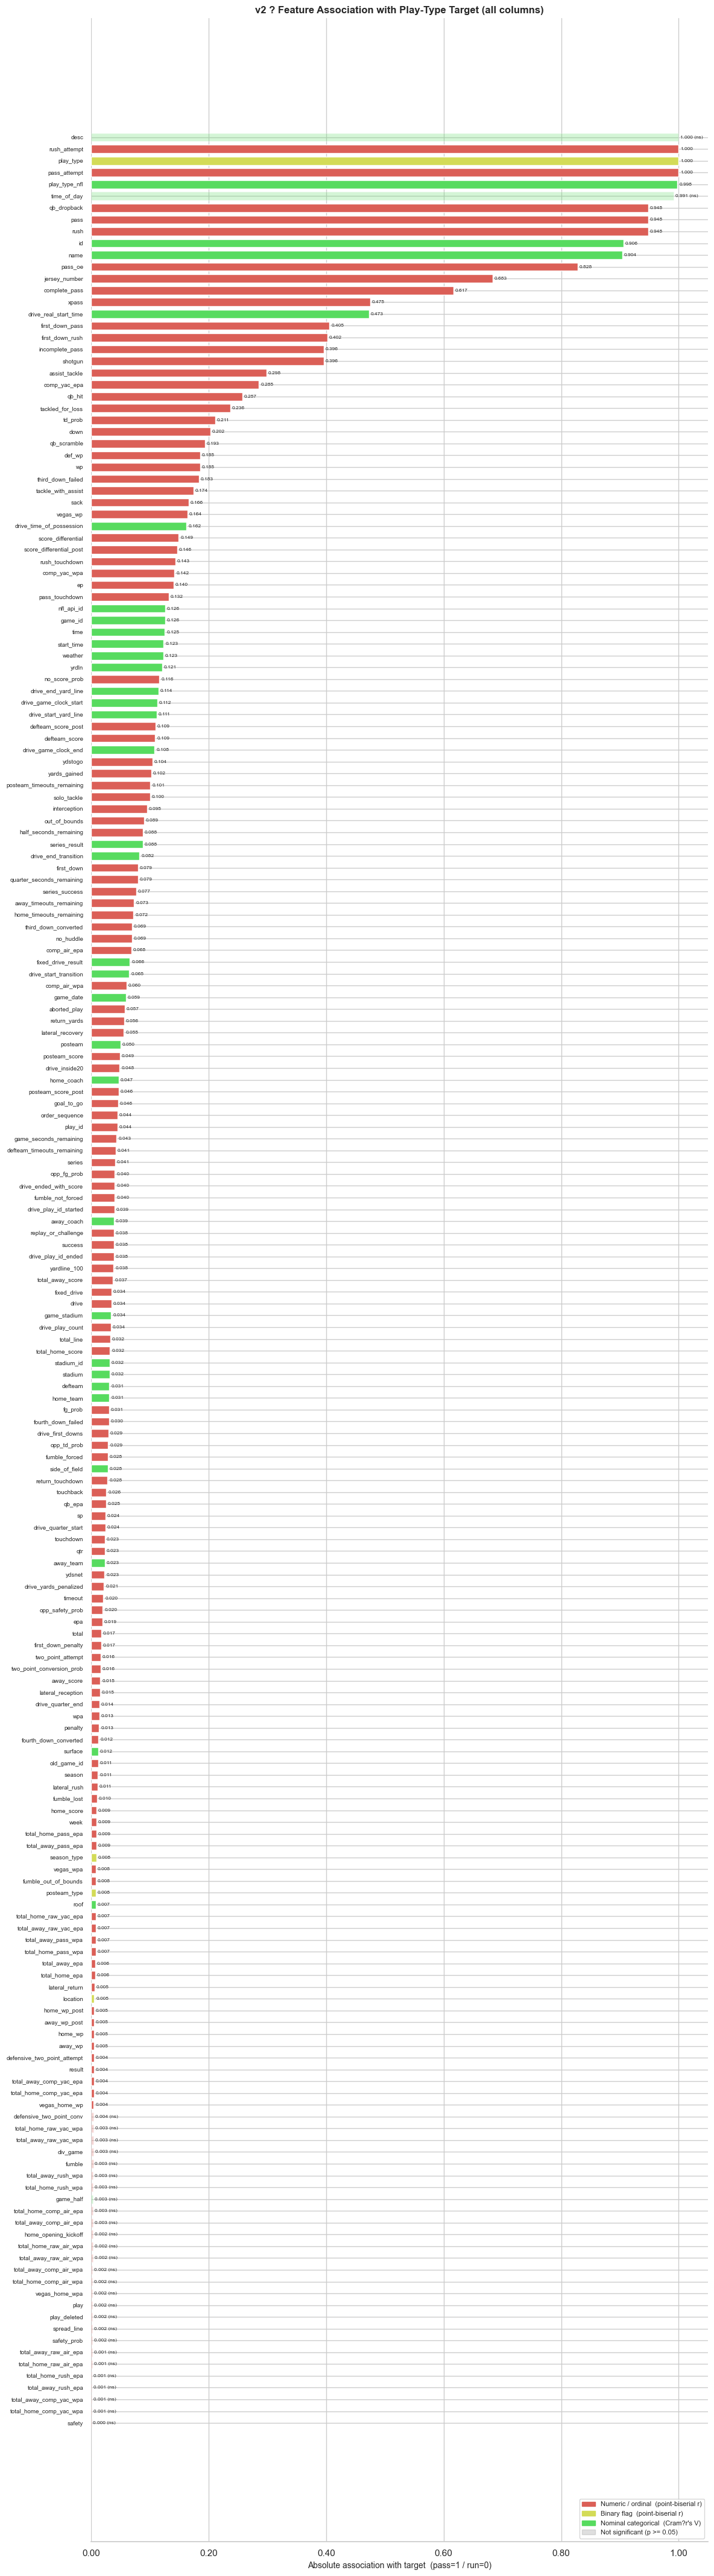

Saved -> C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\figures\eda\v2_all_feature_association.png


In [ ]:

# set color palat
palette = sns.color_palette(PLOT_PALETTE)
plot_df = assoc_df.sort_values("abs_assoc", ascending=True).copy()
n = len(plot_df)

# adjust figure heights dynamically
fig_height = max(8, n * 0.22)
fig, ax = plt.subplots(figsize=(12, fig_height))

# def colors for feature type
type_color_map = {"numeric": palette[0], "binary": palette[1], "categorical": palette[2]}

# significant bars: full opacity; insignificant: faded
bar_colors = []
bar_alphas = []
for _, row in plot_df.iterrows():
    base_color = type_color_map.get(row["type"], palette[3])
    bar_colors.append(base_color)
    bar_alphas.append(1.0 if row["p_value"] < SIGNIFICANCE_ALPHA else 0.25)

# plot horizontal bars
bars = ax.barh(plot_df["feature"], plot_df["abs_assoc"],
               color=bar_colors, edgecolor="white", height=0.7)

# apply per-bar alpha
for bar, alpha in zip(bars, bar_alphas):
    bar.set_alpha(alpha)

# value labels
for bar, val, p in zip(bars, plot_df["abs_assoc"], plot_df["p_value"]):
    label = f"{val:.3f}" if p < SIGNIFICANCE_ALPHA else f"{val:.3f} (ns)"
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            label, va="center", ha="left", fontsize=6)

# add legend
legend_handles = [
    Patch(color=palette[0], label="Numeric / ordinal  (point-biserial r)"),
    Patch(color=palette[1], label="Binary flag  (point-biserial r)"),
    Patch(color=palette[2], label="Nominal categorical  (Cram?r's V)"),
    Patch(color="grey", alpha=0.25, label=f"Not significant (p >= {SIGNIFICANCE_ALPHA})"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="lower right")

# apply labels title and ticks
ax.set_xlabel("Absolute association with target  (pass=1 / run=0)", fontsize=10)
ax.set_title("v2 ? Feature Association with Play-Type Target (all columns)",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.tick_params(axis="y", labelsize=7)

# finalize layout
sns.despine(left=True)
plt.tight_layout()
plt.savefig(FIGURES_EDA / "v2_all_feature_association.png", dpi=PLOT_DPI, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURES_EDA / 'v2_all_feature_association.png'}")


### 2.3 — Distribution by Type

How many features per detected type, and how many are above / below the threshold.

In [ ]:
significant   = assoc_df[assoc_df["p_value"] <  SIGNIFICANCE_ALPHA]
insignificant = assoc_df[assoc_df["p_value"] >= SIGNIFICANCE_ALPHA]

print(f"Significant   (p < {SIGNIFICANCE_ALPHA}): {len(significant)}")
print(f"Insignificant (p >= {SIGNIFICANCE_ALPHA}): {len(insignificant)}")

print("\nBreakdown by type (significant):")
print(significant["type"].value_counts().to_string())

print("\nBreakdown by type (insignificant):")
print(insignificant["type"].value_counts().to_string())


Significant   (p < 0.05): 166
Insignificant (p >= 0.05): 29

Breakdown by type (significant):
type
numeric        130
categorical     32
binary           4

Breakdown by type (insignificant):
type
numeric        26
categorical     3


### 2.4 — Top features above threshold

Compact view of **statistically significant** features (p < 0.05), sorted by association strength. This is the candidate pool for manual pre-snap selection.

In [ ]:
# sorgt significiant features and create based rank
sig_sorted = significant.sort_values("abs_assoc", ascending=False).reset_index(drop=True)
sig_sorted.index = range(1, len(sig_sorted) + 1)
sig_sorted.index.name = "rank"

display(sig_sorted[["feature", "type", "metric", "association", "abs_assoc", "p_value"]])


,feature,type,metric,association,abs_assoc,p_value
rank,,,,,,
1,play_type,binary,point-biserial r,1.0000,1.0000,0.0000
2,rush_attempt,numeric,point-biserial r,-1.0000,1.0000,0.0000
3,pass_attempt,numeric,point-biserial r,1.0000,1.0000,0.0000
4,play_type_nfl,categorical,Cramér's V,0.9981,0.9981,0.0000
5,qb_dropback,numeric,point-biserial r,0.9483,0.9483,0.0000
6,pass,numeric,point-biserial r,0.9482,0.9482,0.0000
7,rush,numeric,point-biserial r,-0.9481,0.9481,0.0000
8,id,categorical,Cramér's V,0.9063,0.9063,0.0000
9,name,categorical,Cramér's V,0.9038,0.9038,0.0000


## Stage 3 — Manual Pre-Snap Selection: Comprehensive Feature Set

In [ ]:
SELECTED_PRESNAP_FEATURES = [
    # ── Situational Core ──────────────────────────────────────────────
    "down",                        # 1st/2nd/3rd/4th down
    "ydstogo",                     # yards needed for first down
    "yardline_100",                # field position (distance to opponent EZ)
    "goal_to_go",                  # binary: goal-to-go situation
    "qtr",                         # quarter (1–4, 5=OT)
    "half_seconds_remaining",      # seconds left in half
    "game_seconds_remaining",      # seconds left in game
    # ── Score & Win Probability ───────────────────────────────────────
    "score_differential",          # posteam_score - defteam_score
    "defteam_score",               # absolute score of defense team
    "wp",                          # win probability pre-snap (model)
    "ep",                          # expected points pre-snap
    # ── Formation / Pre-Snap Alignment ───────────────────────────────
    "shotgun",                     # QB in shotgun? (binary)
    "no_huddle",                   # no-huddle offense? (binary)
    # ── Timeout & Clock Management ────────────────────────────────────
    "posteam_timeouts_remaining",  # timeouts left for offense
    "defteam_timeouts_remaining",  # timeouts left for defense
    # ── Drive Context ─────────────────────────────────────────────────
    "drive_start_transition",      # how the drive started (e.g. KICKOFF, PUNT)
    # ── Game & Season Context ─────────────────────────────────────────
    "season_type",                 # REG vs POST
    # ── Venue / Environment ───────────────────────────────────────────
    "roof",                        # open/closed/retractable/outdoors
    "total_line",                  # Vegas over/under (game total)
]

if SELECTED_PRESNAP_FEATURES:
    # filter sort and rank selected features
    sel_df = assoc_df[assoc_df["feature"].isin(SELECTED_PRESNAP_FEATURES)].sort_values(
        "abs_assoc", ascending=False
    ).reset_index(drop=True)
    sel_df.index = range(1, len(sel_df) + 1)
    sel_df.index.name = "rank"

    print(f"Selected pre-snap features: {len(SELECTED_PRESNAP_FEATURES)}")
    display(sel_df[["feature", "type", "metric", "association", "abs_assoc", "p_value"]])

Selected pre-snap features: 19


,feature,type,metric,association,abs_assoc,p_value
rank,,,,,,
1,shotgun,numeric,point-biserial r,0.3960,0.3960,0.0000
2,down,numeric,point-biserial r,0.2024,0.2024,0.0000
3,wp,numeric,point-biserial r,-0.1851,0.1851,0.0000
4,score_differential,numeric,point-biserial r,-0.1487,0.1487,0.0000
5,ep,numeric,point-biserial r,-0.1401,0.1401,0.0000
6,defteam_score,numeric,point-biserial r,0.1088,0.1088,0.0000
7,ydstogo,numeric,point-biserial r,0.1040,0.1040,0.0000
8,posteam_timeouts_remaining,numeric,point-biserial r,-0.1006,0.1006,0.0000
9,no_huddle,numeric,point-biserial r,0.0695,0.0695,0.0000


## Stage 3 — Manual Pre-Snap Selection: Maxi Feature Set

In [ ]:
SELECTED_PRESNAP_FEATURES = [

    # ── Situational Core ──────────────────────────────────────────────
    "down",                        # 1st/2nd/3rd/4th down
    "ydstogo",                     # yards needed for first down
    "yardline_100",                # field position (distance to opponent EZ)
    "goal_to_go",                  # binary: goal-to-go situation
    "qtr",                         # quarter (1–4, 5=OT)
    "half_seconds_remaining",      # seconds left in half
    "quarter_seconds_remaining",   # seconds left in quarter
    "game_seconds_remaining",      # seconds left in game
    # ── Score & Win Probability ───────────────────────────────────────
    "score_differential",          # posteam_score - defteam_score
    "posteam_score",               # absolute score of possession team
    "defteam_score",               # absolute score of defense team
    "wp",                          # win probability pre-snap (model)
    "vegas_wp",                    # Vegas-based win probability
    "no_score_prob",               # EP component: prob of no score
    "td_prob",                     # EP component: prob of TD
    "fg_prob",                     # EP component: prob of FG
    "opp_fg_prob",                 # EP component: prob opp FG
    "opp_td_prob",                 # EP component: prob opp TD
    "ep",                          # expected points pre-snap
    # ── Formation / Pre-Snap Alignment ───────────────────────────────
    "shotgun",                     # QB in shotgun? (binary)
    "no_huddle",                   # no-huddle offense? (binary)
    # ── Timeout & Clock Management ────────────────────────────────────
    "posteam_timeouts_remaining",  # timeouts left for offense
    "defteam_timeouts_remaining",  # timeouts left for defense
    "home_timeouts_remaining",     # raw home timeouts
    "away_timeouts_remaining",     # raw away timeouts
    # ── Drive Context ─────────────────────────────────────────────────
    "drive_play_count",            # plays already run in this drive
    "drive_first_downs",           # first downs earned in drive
    "drive_inside20",              # is drive in red zone?
    "drive_ended_with_score",      # did drive end with score? (caution*)
    "ydsnet",                      # net yards gained on drive so far
    # ── Game & Season Context ─────────────────────────────────────────
    "season",                      # season year
    "week",                        # week of season
    "season_type",                 # REG vs POST
    "qtr",                         # already included above (deduplicate!)
    # ── Teams & Matchup ───────────────────────────────────────────────
    "posteam",                     # possession team (categorical)
    "defteam",                     # defensive team (categorical)
    "home_team",                   # home team identifier
    "posteam_type",                # home or away (binary)
    "location",                    # home/away/neutral (binary)
    # ── Coaching ──────────────────────────────────────────────────────
    "home_coach",                  # head coach home team
    "away_coach",                  # head coach away team
    # ── Venue / Environment ───────────────────────────────────────────
    "roof",                        # open/closed/retractable/outdoors
    "surface",                     # grass vs turf
    "weather",                     # weather description (categorical)
    "total_line",                  # Vegas over/under (game total)
    # ── Cumulative Team EPA (game-level context) ──────────────────────
    "total_home_epa",              # cumulative EPA home team in game
    "total_away_epa",              # cumulative EPA away team in game
    "total_home_pass_epa",         # cumulative pass EPA home
    "total_away_pass_epa",         # cumulative pass EPA away
]

if SELECTED_PRESNAP_FEATURES:
     # filter sort and rank selected features
    sel_df = assoc_df[assoc_df["feature"].isin(SELECTED_PRESNAP_FEATURES)].sort_values(
        "abs_assoc", ascending=False
    ).reset_index(drop=True)
    sel_df.index = range(1, len(sel_df) + 1)
    sel_df.index.name = "rank"

    print(f"Selected pre-snap features: {len(SELECTED_PRESNAP_FEATURES)}")
    display(sel_df[["feature", "type", "metric", "association", "abs_assoc", "p_value"]])

Selected pre-snap features: 49


,feature,type,metric,association,abs_assoc,p_value
rank,,,,,,
1,shotgun,numeric,point-biserial r,0.3960,0.3960,0.0000
2,td_prob,numeric,point-biserial r,-0.2111,0.2111,0.0000
3,down,numeric,point-biserial r,0.2024,0.2024,0.0000
4,wp,numeric,point-biserial r,-0.1851,0.1851,0.0000
5,vegas_wp,numeric,point-biserial r,-0.1639,0.1639,0.0000
6,score_differential,numeric,point-biserial r,-0.1487,0.1487,0.0000
7,ep,numeric,point-biserial r,-0.1401,0.1401,0.0000
8,weather,categorical,Cramér's V,0.1229,0.1229,0.0000
9,no_score_prob,numeric,point-biserial r,0.1158,0.1158,0.0000
